
===== WITHOUT HYPERPARAMETER TUNING =====

LINEAR REGRESSION
MAE : 0.706
RMSE: 0.941
R2  : 0.464

RIDGE REGRESSION
MAE : 0.579
RMSE: 0.802
R2  : 0.611

LASSO REGRESSION
MAE : 0.629
RMSE: 0.82
R2  : 0.593


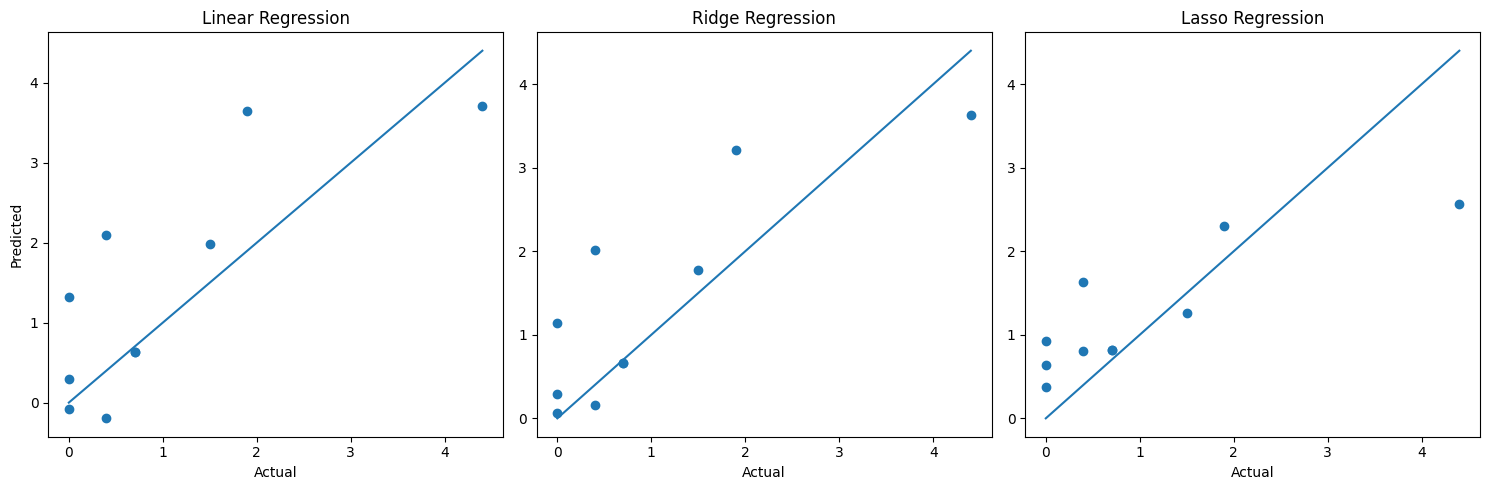

In [1]:
# ============================================
# MULTIPLE + RIDGE + LASSO (WITHOUT TUNING)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# --------------------------------------------
# Create Dataset (same as your experiment)
# --------------------------------------------
data = {
    'age': [52,53,70,61,62,58,58,55,46,54,71,43,34,51,52,34,51,54,50,58,
            60,67,45,63,42,61,44,58,56,55,44,50,57,70,50,46,51,59,64,57],
    'sex': [1,1,1,1,0,0,1,1,1,1,0,0,0,1,1,0,0,1,0,1,
            1,0,1,0,0,0,1,0,1,0,1,0,1,1,1,1,1,1,1,1],
    'cp': [0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,2,0,1,2,
           2,0,0,2,2,0,2,1,2,0,0,1,0,2,2,2,3,0,0,2],
    'trestbps': [125,140,145,148,138,100,114,160,120,122,112,132,118,140,128,118,140,124,120,140,
                 140,106,104,135,120,145,130,136,130,180,120,120,130,160,129,150,125,138,128,128],
    'chol': [212,203,174,203,294,248,318,289,249,286,149,341,210,298,204,210,308,266,244,211,
             185,223,208,252,209,307,233,319,256,327,169,244,131,269,196,231,213,271,263,229],
    'fbs': [0,1,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,
            0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0],
    'restecg': [1,0,1,1,1,0,2,0,0,0,1,0,1,1,1,1,0,0,1,0,
                0,1,0,0,1,0,1,0,0,2,1,1,1,1,1,1,0,0,1,0],
    'thalach': [168,155,125,161,106,122,140,145,144,116,125,136,192,122,156,192,142,109,162,165,
                155,142,148,172,173,146,179,152,142,117,144,162,115,112,163,147,125,182,105,150],
    'exang': [0,1,1,0,0,0,0,1,0,1,0,1,0,1,1,0,0,1,0,0,
              0,0,1,0,0,1,1,0,1,1,1,0,1,1,0,0,1,0,1,0],
    'oldpeak': [1.0,3.1,2.6,0.0,1.9,1.0,4.4,0.8,0.8,3.2,1.6,3.0,0.7,4.2,1.0,0.7,1.5,2.2,1.1,0.0,
                3.0,0.3,3.0,0.0,0.0,1.0,0.4,0.0,0.6,3.4,2.8,1.1,1.2,2.9,0.0,3.6,1.4,0.0,0.2,0.4],
    'slope': [2,0,0,2,1,1,0,1,2,1,1,1,2,1,1,2,2,1,2,2,
              1,2,1,2,1,1,2,2,1,1,0,2,1,1,2,1,2,2,1,1],
    'ca': [2,0,0,1,3,0,3,1,0,2,0,0,0,3,0,0,1,1,0,0,
           0,2,0,0,0,0,0,2,1,0,0,0,1,1,0,0,1,0,1,1],
    'thal': [3,3,3,3,2,2,1,3,3,2,2,3,2,3,0,2,2,3,2,2,
             2,2,2,2,2,3,2,2,1,2,1,2,3,3,2,2,2,2,3,3],
    'target': [0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,1,0,1,1,
               0,1,1,1,1,0,1,0,0,0,0,1,0,0,1,0,1,1,1,0]
}

df = pd.DataFrame(data)

# --------------------------------------------
# Prepare Data
# --------------------------------------------
X = df.drop(['oldpeak', 'target'], axis=1)
y = df['oldpeak']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# --------------------------------------------
# Models (NO TUNING)
# --------------------------------------------
linear = LinearRegression()
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.1)

linear.fit(X_train, y_train)
ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)

# Predictions
y_pred_linear = linear.predict(X_test)
y_pred_ridge = ridge.predict(X_test)
y_pred_lasso = lasso.predict(X_test)

# --------------------------------------------
# Evaluation
# --------------------------------------------
print("\n===== WITHOUT HYPERPARAMETER TUNING =====")

def evaluate(name, y_true, y_pred):
    print(f"\n{name}")
    print("MAE :", round(mean_absolute_error(y_true, y_pred), 3))
    print("RMSE:", round(np.sqrt(mean_squared_error(y_true, y_pred)), 3))
    print("R2  :", round(r2_score(y_true, y_pred), 3))

evaluate("LINEAR REGRESSION", y_test, y_pred_linear)
evaluate("RIDGE REGRESSION", y_test, y_pred_ridge)
evaluate("LASSO REGRESSION", y_test, y_pred_lasso)

# --------------------------------------------
# Graph Output (Actual vs Predicted)
# --------------------------------------------
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.scatter(y_test, y_pred_linear)
plt.plot([y.min(), y.max()], [y.min(), y.max()])
plt.title("Linear Regression")
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.subplot(1,3,2)
plt.scatter(y_test, y_pred_ridge)
plt.plot([y.min(), y.max()], [y.min(), y.max()])
plt.title("Ridge Regression")
plt.xlabel("Actual")

plt.subplot(1,3,3)
plt.scatter(y_test, y_pred_lasso)
plt.plot([y.min(), y.max()], [y.min(), y.max()])
plt.title("Lasso Regression")
plt.xlabel("Actual")

plt.tight_layout()
plt.show()



===== WITH HYPERPARAMETER TUNING =====

LINEAR REGRESSION
MAE : 0.706
RMSE: 0.941
R2  : 0.464

Best Ridge Alpha: 100

RIDGE REGRESSION (TUNED)
MAE : 0.966
RMSE: 1.184
R2  : 0.151

Best Lasso Alpha: 1

LASSO REGRESSION (TUNED)
MAE : 1.262
RMSE: 1.449
R2  : -0.272


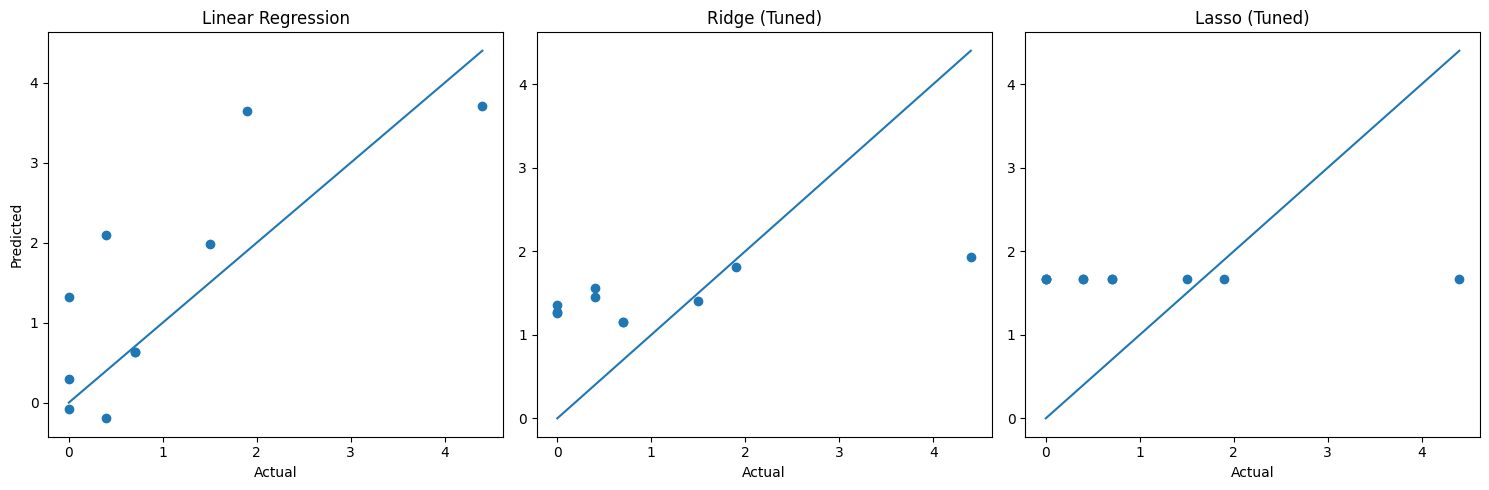

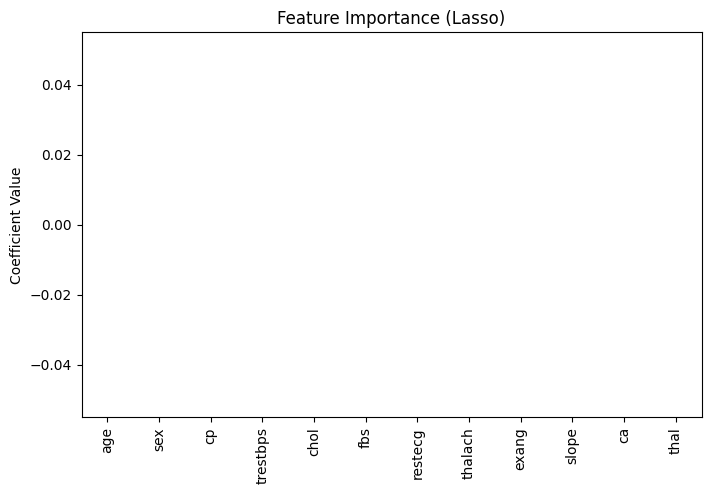

In [2]:
# ============================================
# MULTIPLE + RIDGE + LASSO (WITH TUNING)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# --------------------------------------------
# Create Dataset
# --------------------------------------------
data = {
    'age': [52,53,70,61,62,58,58,55,46,54,71,43,34,51,52,34,51,54,50,58,
            60,67,45,63,42,61,44,58,56,55,44,50,57,70,50,46,51,59,64,57],
    'sex': [1,1,1,1,0,0,1,1,1,1,0,0,0,1,1,0,0,1,0,1,
            1,0,1,0,0,0,1,0,1,0,1,0,1,1,1,1,1,1,1,1],
    'cp': [0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,2,0,1,2,
           2,0,0,2,2,0,2,1,2,0,0,1,0,2,2,2,3,0,0,2],
    'trestbps': [125,140,145,148,138,100,114,160,120,122,112,132,118,140,128,118,140,124,120,140,
                 140,106,104,135,120,145,130,136,130,180,120,120,130,160,129,150,125,138,128,128],
    'chol': [212,203,174,203,294,248,318,289,249,286,149,341,210,298,204,210,308,266,244,211,
             185,223,208,252,209,307,233,319,256,327,169,244,131,269,196,231,213,271,263,229],
    'fbs': [0,1,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,
            0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0],
    'restecg': [1,0,1,1,1,0,2,0,0,0,1,0,1,1,1,1,0,0,1,0,
                0,1,0,0,1,0,1,0,0,2,1,1,1,1,1,1,0,0,1,0],
    'thalach': [168,155,125,161,106,122,140,145,144,116,125,136,192,122,156,192,142,109,162,165,
                155,142,148,172,173,146,179,152,142,117,144,162,115,112,163,147,125,182,105,150],
    'exang': [0,1,1,0,0,0,0,1,0,1,0,1,0,1,1,0,0,1,0,0,
              0,0,1,0,0,1,1,0,1,1,1,0,1,1,0,0,1,0,1,0],
    'oldpeak': [1.0,3.1,2.6,0.0,1.9,1.0,4.4,0.8,0.8,3.2,1.6,3.0,0.7,4.2,1.0,0.7,1.5,2.2,1.1,0.0,
                3.0,0.3,3.0,0.0,0.0,1.0,0.4,0.0,0.6,3.4,2.8,1.1,1.2,2.9,0.0,3.6,1.4,0.0,0.2,0.4],
    'slope': [2,0,0,2,1,1,0,1,2,1,1,1,2,1,1,2,2,1,2,2,
              1,2,1,2,1,1,2,2,1,1,0,2,1,1,2,1,2,2,1,1],
    'ca': [2,0,0,1,3,0,3,1,0,2,0,0,0,3,0,0,1,1,0,0,
           0,2,0,0,0,0,0,2,1,0,0,0,1,1,0,0,1,0,1,1],
    'thal': [3,3,3,3,2,2,1,3,3,2,2,3,2,3,0,2,2,3,2,2,
             2,2,2,2,2,3,2,2,1,2,1,2,3,3,2,2,2,2,3,3],
    'target': [0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,1,0,1,1,
               0,1,1,1,1,0,1,0,0,0,0,1,0,0,1,0,1,1,1,0]
}

df = pd.DataFrame(data)

# --------------------------------------------
# Prepare Data
# --------------------------------------------
X = df.drop(['oldpeak', 'target'], axis=1)
y = df['oldpeak']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# --------------------------------------------
# Linear Regression (baseline)
# --------------------------------------------
linear = LinearRegression()
linear.fit(X_train, y_train)
y_pred_linear = linear.predict(X_test)

# --------------------------------------------
# Hyperparameter Tuning
# --------------------------------------------
alpha_values = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

# Ridge Tuning
ridge = Ridge()
ridge_grid = GridSearchCV(ridge, alpha_values, cv=5, scoring='neg_mean_squared_error')
ridge_grid.fit(X_train, y_train)

best_ridge = ridge_grid.best_estimator_
y_pred_ridge = best_ridge.predict(X_test)

# Lasso Tuning
lasso = Lasso(max_iter=10000)
lasso_grid = GridSearchCV(lasso, alpha_values, cv=5, scoring='neg_mean_squared_error')
lasso_grid.fit(X_train, y_train)

best_lasso = lasso_grid.best_estimator_
y_pred_lasso = best_lasso.predict(X_test)

# --------------------------------------------
# Evaluation
# --------------------------------------------
print("\n===== WITH HYPERPARAMETER TUNING =====")

def evaluate(name, y_true, y_pred):
    print(f"\n{name}")
    print("MAE :", round(mean_absolute_error(y_true, y_pred), 3))
    print("RMSE:", round(np.sqrt(mean_squared_error(y_true, y_pred)), 3))
    print("R2  :", round(r2_score(y_true, y_pred), 3))

evaluate("LINEAR REGRESSION", y_test, y_pred_linear)

print("\nBest Ridge Alpha:", ridge_grid.best_params_['alpha'])
evaluate("RIDGE REGRESSION (TUNED)", y_test, y_pred_ridge)

print("\nBest Lasso Alpha:", lasso_grid.best_params_['alpha'])
evaluate("LASSO REGRESSION (TUNED)", y_test, y_pred_lasso)

# --------------------------------------------
# Graph Output
# --------------------------------------------
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.scatter(y_test, y_pred_linear)
plt.plot([y.min(), y.max()], [y.min(), y.max()])
plt.title("Linear Regression")
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.subplot(1,3,2)
plt.scatter(y_test, y_pred_ridge)
plt.plot([y.min(), y.max()], [y.min(), y.max()])
plt.title("Ridge (Tuned)")
plt.xlabel("Actual")

plt.subplot(1,3,3)
plt.scatter(y_test, y_pred_lasso)
plt.plot([y.min(), y.max()], [y.min(), y.max()])
plt.title("Lasso (Tuned)")
plt.xlabel("Actual")

plt.tight_layout()
plt.show()

# --------------------------------------------
# Lasso Feature Selection
# --------------------------------------------
lasso_coeff = pd.Series(best_lasso.coef_, index=X.columns)

plt.figure(figsize=(8,5))
lasso_coeff.plot(kind='bar')
plt.title("Feature Importance (Lasso)")
plt.ylabel("Coefficient Value")
plt.show()
